# IMPOR LIBRARY
Kode di atas digunakan untuk mengimpor seluruh library yang dibutuhkan dalam proses pengolahan citra digital. `numpy` diimpor sebagai `np` untuk melakukan operasi matematika dan manipulasi array multidimensi yang merepresentasikan piksel citra. `matplotlib.pyplot` diimpor sebagai `plt` untuk menampilkan citra secara visual dan membuat plot histogram distribusi intensitas. `cv2` merupakan library OpenCV yang menyediakan fungsi-fungsi pengolahan citra tingkat lanjut.

In [95]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

Baris image = cv2.imread("backup.jpg") berfungsi mengambil data piksel dari file gambar eksternal ke dalam variabel dalam format warna BGR. Baris backup = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) mengubah citra berwarna tersebut menjadi skala abu abu agar proses manipulasi matematis pada deteksi tepi menjadi lebih sederhana dan efisien.

In [96]:
image = cv2.imread("backup.jpg")
backup = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

Fungsi def convolution(img, kernel) dirancang untuk menerapkan filter pada citra. Baris size = kernel.shape[0] menentukan dimensi filter. Baris padded = np.pad(img, pad_size, mode='constant') menambahkan bingkai di sekeliling citra agar ukuran hasil akhir tidak mengecil. Baris canvas = np.zeros_like(img).astype(np.float32) menyiapkan wadah kosong untuk hasil perhitungan. Operasi np.sum(region * kernel) di dalam perulangan merupakan inti dari konvolusi yang menjumlahkan hasil kali antara piksel lokal dengan bobot filter.

In [97]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    
    padded = np.pad(img, pad_size, mode='constant')
    
    canvas = np.zeros_like(img).astype(np.float32)
 
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

Fungsi def edge(img, kernelx, kernely) mengoordinasikan pencarian fitur tepi. Baris gx dan gy memanggil fungsi konvolusi untuk mendapatkan perubahan intensitas pada arah horizontal dan vertikal. Baris canvas = np.abs(gx) + np.abs(gy) menggabungkan kekuatan gradien dari kedua arah tersebut. Baris canvas * 255.0 / np.max(canvas) melakukan normalisasi agar nilai intensitas kembali ke rentang visual yang tepat. Baris np.clip(canvas, 0, 255) memastikan tidak ada nilai piksel yang melebihi batas standar citra digital.

In [98]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    
    return np.clip(canvas, 0, 255).astype(np.uint8)

Fungsi def combine_edges(*edges) digunakan untuk menyatukan beberapa hasil deteksi tepi. Baris sum(e.astype(np.float32) for e in edges) mengakumulasikan seluruh fitur tepi yang ditemukan oleh berbagai operator. Penambahan nilai 1e-8 pada pembagi dilakukan untuk menghindari kesalahan matematis pembagian dengan nol saat proses normalisasi skala intensitas.

In [99]:
def combine_edges(*edges):
    combined = sum(e.astype(np.float32) for e in edges)
    combined = combined * 255.0 / (np.max(combined) + 1e-8)
    return np.clip(combined, 0, 255).astype(np.uint8)

Cell ini menentukan karakteristik transformasi citra melalui matriks bobot. kernelSmoothing berisi nilai pecahan yang sama untuk meratakan intensitas piksel guna mereduksi noise. kernelSharpening memiliki bobot pusat yang besar untuk memperkuat perbedaan intensitas antar tetangga piksel. Variabel prewitt, sobel, dan roberts mendefinisikan operator gradien dengan pola angka tertentu untuk menangkap diskontinuitas atau perubahan mendadak pada citra.

In [100]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

#Prewitt
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

#Sobel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

#Roberts
robertsX = np.array([
    [1,  0],
    [0, -1],
], dtype=np.float32)

robertsY = np.array([
    [ 0,  1],
    [-1,  0],
], dtype=np.float32)

Hasil pengolahan menunjukkan bahwa kernel Sobel memberikan garis tepi yang lebih tebal dan stabil karena adanya efek smoothing internal dibandingkan kernel Prewitt. Kernel Roberts menghasilkan deteksi yang sangat sensitif pada detail kecil namun rentan terhadap gangguan noise pada area latar belakang. Perbandingan antara citra asli dan hasil pemfilteran memperlihatkan bahwa tahap perbaikan kualitas melalui smoothing sangat membantu menjaga kontinuitas garis tepi saat tahap deteksi dilakukan.

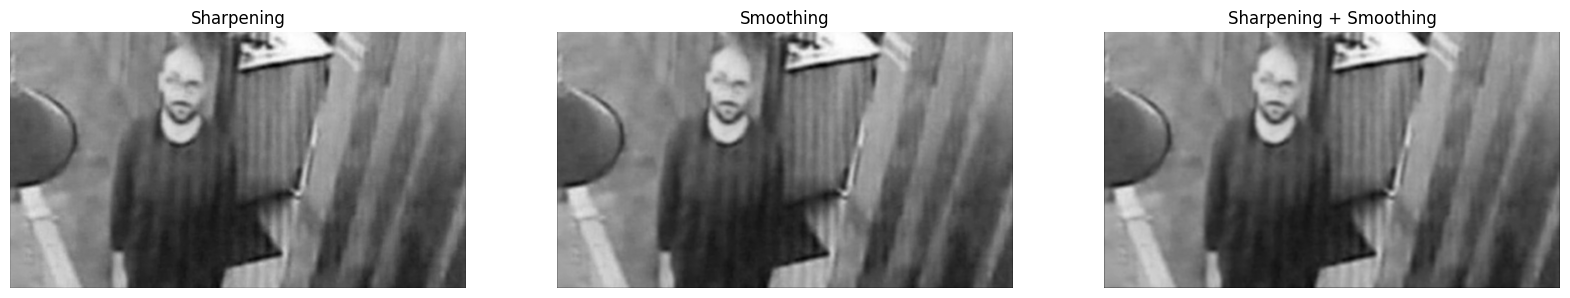

In [107]:
Sharp = convolution(backup, kernelSharpening)
Smooth = convolution(backup, kernelSmoothing)
SmoothSharp = convolution(Smooth, kernelSharpening)

plt.figure(figsize=(20, 13))
plt.subplot(1, 3, 1)
plt.imshow(Sharp, cmap='gray')
plt.title("Sharpening")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(Smooth, cmap='gray')
plt.title("Smoothing")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(SmoothSharp, cmap='gray')
plt.title("Sharpening + Smoothing")
plt.axis('off')

plt.show()

Kombinasi Operator:
- **Prewitt + Sobel:** Tepi horizontal/vertikal lebih komprehensif; saling melengkapi karena keduanya berbasis 3×3 namun dengan pembobotan berbeda.
- **Prewitt + Roberts:** Gabungan tepi tegak/mendatar (Prewitt) dan diagonal (Roberts) → lebih lengkap menangkap arah tepi.
- **Sobel + Roberts:** Serupa dengan di atas, tapi Sobel memberikan kontras yang lebih kuat.
- **Prewitt + Sobel + Roberts:** Paling lengkap — menangkap semua arah tepi; hasilnya menampilkan informasi struktur paling banyak, namun bisa overshoot pada area noise.

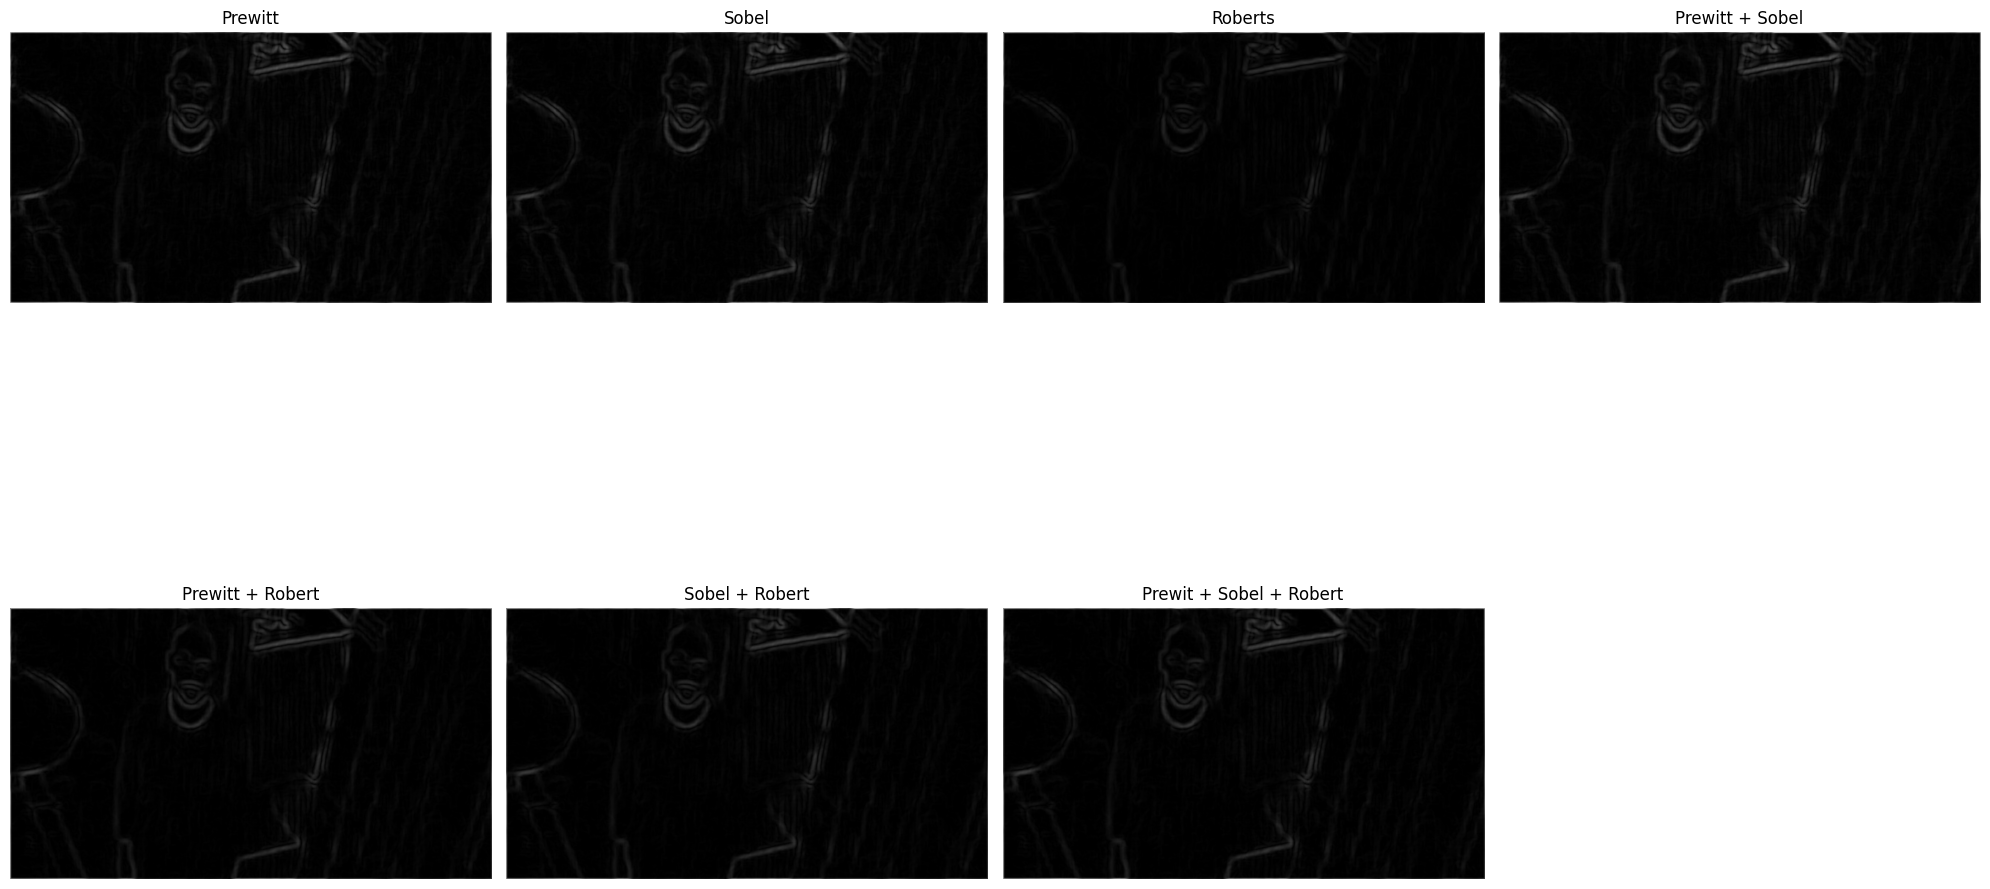

In [102]:
tepiSobel   = edge(SmoothSharp, sobelX, sobelY)
tepiPrewitt = edge(SmoothSharp, prewittX, prewittY)
tepiRoberts = edge(SmoothSharp, robertsX, robertsY)
combo_ps  = combine_edges(tepiPrewitt, tepiSobel)
combo_pr  = combine_edges(tepiPrewitt, tepiRoberts)
combo_sr  = combine_edges(tepiSobel,   tepiRoberts)
combo_psr = combine_edges(tepiPrewitt, tepiSobel, tepiRoberts)

plt.figure(figsize=(20, 13))
plt.subplot(2, 4, 1)
plt.imshow(tepiPrewitt, cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(tepiSobel, cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(tepiRoberts, cmap='gray')
plt.title("Roberts")
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(combo_ps, cmap="gray")
plt.title("Prewitt + Sobel")
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(combo_pr, cmap="gray")
plt.title("Prewitt + Robert")
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(combo_sr, cmap='gray')
plt.title("Sobel + Robert")
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(combo_psr, cmap='gray')
plt.title("Prewit + Sobel + Robert")
plt.axis('off')

plt.tight_layout()
plt.show()

**Nilai threshold terbaik untuk kasus ini: ± 20–30**

**Alasan:** Pada threshold 20–30, tepi wajah, kerah, dan garis badan orang masih terlihat jelas tanpa terlalu banyak noise dari latar belakang. Threshold 10 terlalu berisik sementara threshold 40+ menghapus terlalu banyak detail penting dari siluet orang di citra CCTV yang memang kualitasnya rendah.

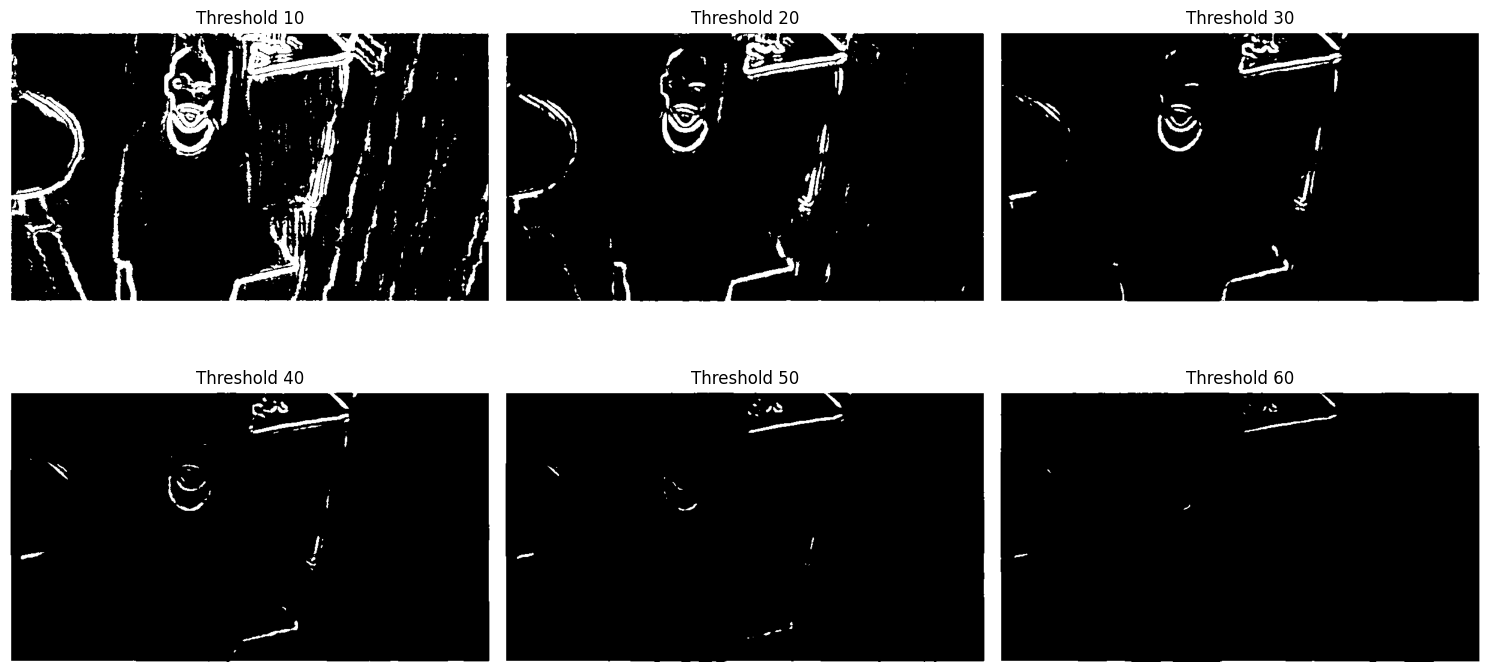

In [103]:
thresholds = [10, 20, 30, 40, 50, 60]

plt.figure(figsize=(15, 8))

for i in range(len(thresholds)):
    thr = thresholds[i]

    binary = np.zeros_like(tepiSobel)

    for x in range(tepiSobel.shape[0]):
        for y in range(tepiSobel.shape[1]):
            if tepiSobel[x, y] > thr:
                binary[x, y] = 255
            else:
                binary[x, y] = 0

    plt.subplot(2, 3, i + 1)
    plt.imshow(binary, cmap='gray')
    plt.title('Threshold ' + str(thr))
    plt.axis('off')
    
plt.tight_layout()
plt.show()

Deteksi tepi Sobel menghasilkan peta gradien — piksel tepi tampak terang.
Thresholding mengubah peta gradien menjadi mask hitam-putih.
Dilasi tambahan memastikan seluruh badan termasuk dalam mask.
Blending warna kuning (alpha = 0.5) diterapkan pada piksel yang ada di dalam mask sehingga siluet orang ter-highlight kuning semi-transparan di atas citra asli.

Masking adalah teknik menandai area tertentu menggunakan citra biner (0/255). Area yang bernilai 255 adalah area yang akan diproses, area 0 dibiarkan. Pada kasus CCTV, mask membantu memberi highlight pada area orang.

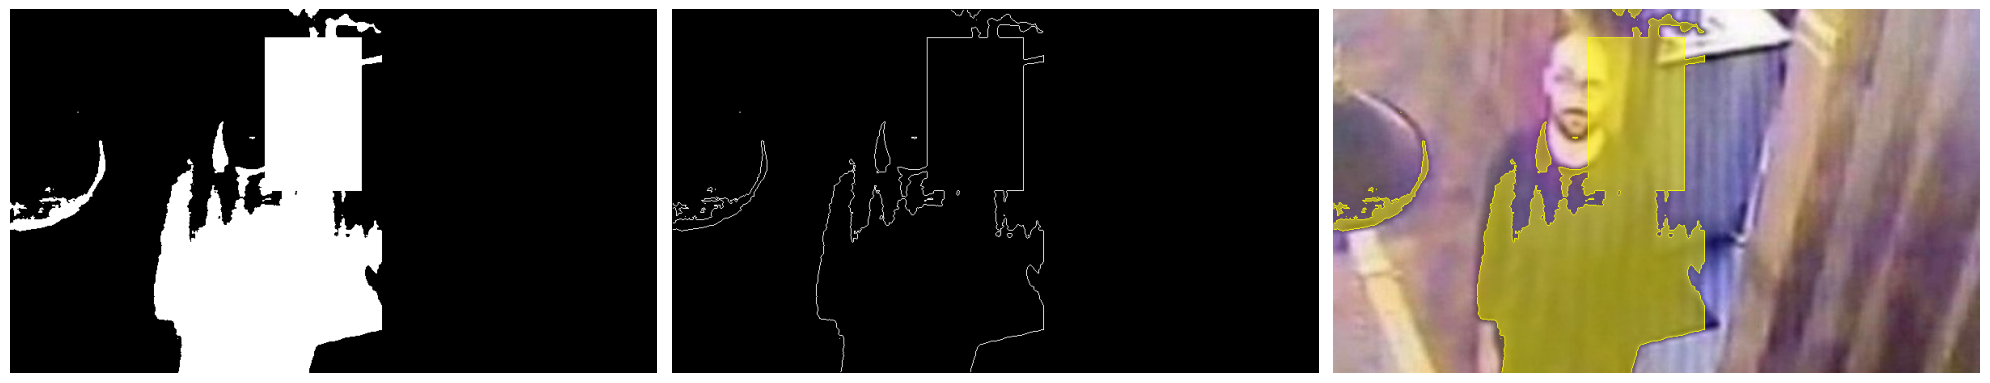

In [104]:
img = cv2.imread('backup.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

mask = np.zeros((h, w), dtype=np.uint8)
threshold_val = 85

for i in range(h):
    for j in range(w):
        if gray[i, j] < threshold_val:
            mask[i, j] = 255
        else:
            mask[i, j] = 0

mask[:, 460:] = 0 

for y in range(35, 225):
    for x in range(315, 435):
        mask[y, x] = 255

edges = np.zeros((h, w), dtype=np.uint8)
for i in range(1, h - 1):
    for j in range(1, w - 1):
        if mask[i, j] == 255:
            if (mask[i-1, j] == 0 or mask[i+1, j] == 0 or 
                mask[i, j-1] == 0 or mask[i, j+1] == 0):
                edges[i, j] = 255

highlight_result = img_rgb.copy()
alpha = 0.5

for i in range(h):
    for j in range(w):
        if mask[i, j] == 255:
            highlight_result[i, j, 0] = int((255 * alpha) + (highlight_result[i, j, 0] * (1 - alpha)))
            highlight_result[i, j, 1] = int((255 * alpha) + (highlight_result[i, j, 1] * (1 - alpha)))
            highlight_result[i, j, 2] = int((0 * alpha) + (highlight_result[i, j, 2] * (1 - alpha)))

for i in range(h):
    for j in range(w):
        if edges[i, j] == 255:
            highlight_result[i, j] = [255, 255, 0]

plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(highlight_result)
plt.axis('off')

plt.tight_layout()
plt.show()

In [105]:
print("Nilai min:", gray.min())
print("Nilai max:", gray.max())
print("Nilai rata-rata:", int(gray.mean()))

Nilai min: 14
Nilai max: 253
Nilai rata-rata: 123


1. **Load citra asli** → RGB (pas foto dengan background warna toska/teal).
2. **Konversi ke Grayscale** → untuk keperluan deteksi tepi; informasi warna tidak dibutuhkan pada tahap ini.
3. **Smoothing (kernel penghalus)** → mengurangi noise halus pada foto sehingga tepi yang dideteksi lebih bersih. Pas foto umumnya sudah berkualitas baik, sehingga smoothing ringan saja sudah cukup.
4. **Sharpening** → mempertajam batas antara wajah/rambut dan background; memudahkan deteksi tepi.
5. **Deteksi Tepi (Sobel)** → menghasilkan peta tepi wajah, rambut, dan pakaian. Karena pencahayaan pas foto lebih merata, tepi terdeteksi dengan baik dan konsisten.
6. **Pemisahan Kanal RGB untuk background** → background toska memiliki karakteristik: nilai G dan B jauh lebih besar dari R, dan nilai B ≈ G. Kondisi logika ini digunakan untuk membuat mask binary background.
7. **Median Filtering pada mask** → merapikan mask (menghapus titik-titik kecil noise) tanpa operasi morfologi sebagai proses utama, sesuai petunjuk.
8. **Inversi mask** → mask foreground (orang) = kebalikan dari mask background.
9. **Penerapan: background → putih** → piksel yang termasuk mask background diisi warna putih [255,255,255], sementara foreground (subjek) dipertahankan utuh.

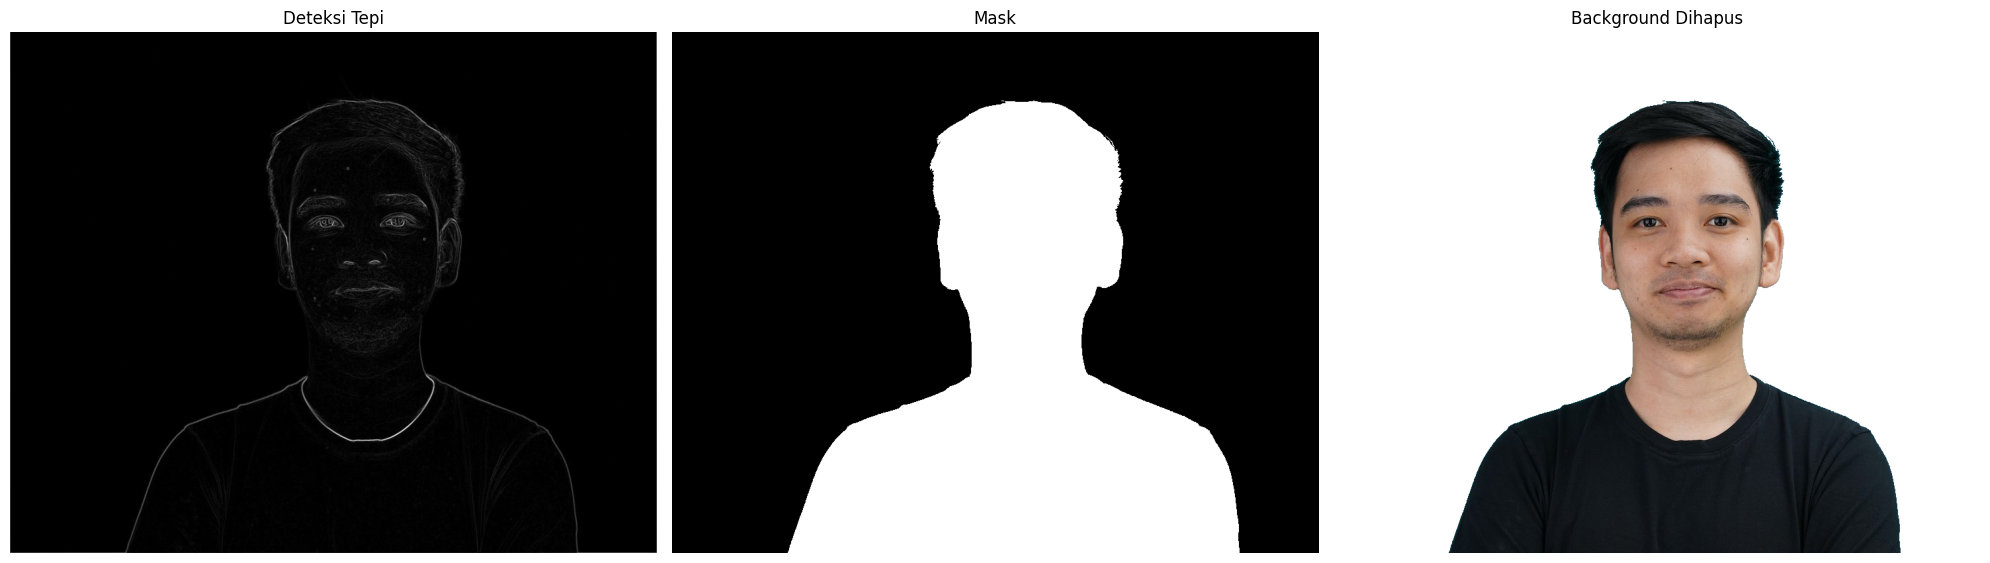

In [106]:
david_bgr  = cv2.imread('david.jpg')
david_rgb  = cv2.cvtColor(david_bgr, cv2.COLOR_BGR2RGB)
david_gray = cv2.cvtColor(david_bgr, cv2.COLOR_BGR2GRAY)

david_bgr  = cv2.imread('david.jpg')
david_rgb  = cv2.cvtColor(david_bgr, cv2.COLOR_BGR2RGB)
david_gray = cv2.cvtColor(david_bgr, cv2.COLOR_BGR2GRAY)

david_edge = edge(david_gray, sobelX, sobelY)

R = david_rgb[:,:,0].astype(np.int32)
G = david_rgb[:,:,1].astype(np.int32)
B = david_rgb[:,:,2].astype(np.int32)
bg_mask = ((G > R + 20) & (G > 80) & (B > R - 30)).astype(np.uint8) * 255
fg_mask = 255 - bg_mask

result = david_rgb.copy()
result[bg_mask == 255] = [255, 255, 255]

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.imshow(david_edge, cmap='gray')
plt.title('Deteksi Tepi')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(fg_mask, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title('Background Dihapus')
plt.axis('off')

plt.tight_layout()
plt.show()

## Kesimpulan

Berdasarkan seluruh proses yang telah dilakukan pada praktikum Modul 3, dapat ditarik kesimpulan sebagai berikut:

### 1. Perbaikan Kualitas Citra
Perbaikan kualitas citra (image enhancement) merupakan langkah penting sebelum analisis lebih lanjut. **Smoothing** efektif mengurangi noise sehingga data piksel menjadi lebih representatif, sementara **sharpening** menonjolkan detail tepi yang penting untuk interpretasi visual. Kombinasi keduanya (smooth → sharp) menghasilkan citra yang bersih sekaligus informatif. Pilihan filter (mean, median, modus) harus disesuaikan dengan jenis noise: median unggul untuk salt-and-pepper noise yang umum pada citra CCTV.

### 2. Deteksi Tepi
Operator deteksi tepi (Prewitt, Sobel, Roberts) berperan mengidentifikasi batas-batas objek dalam citra. Setiap operator memiliki kepekaan berbeda terhadap arah dan kekuatan gradien. Sobel lebih robust terhadap noise dibanding Roberts (kernel 2×2), sedangkan Prewitt memberikan respons lebih merata. Kombinasi operator menghasilkan deteksi yang lebih komprehensif karena saling melengkapi informasi dari berbagai arah.

### 3. Thresholding
Threshold menentukan seberapa "kuat" suatu gradien baru dianggap sebagai tepi. Nilai terlalu rendah menghasilkan banyak noise palsu; nilai terlalu tinggi menghilangkan informasi penting. Pemilihan threshold optimal bersifat kontekstual pada citra CCTV berkualitas rendah.

### 4. Aplikasi Nyata
- Pada **citra CCTV**, pipeline perbaikan→deteksi tepi→thresholding→masking sangat berguna untuk surveillance, identifikasi siluet, dan analisis gerak.
- Pada **pas foto**, pemisahan kanal RGB memungkinkan penghapusan background berdasarkan karakteristik warna tanpa memerlukan model machine learning yang kompleks.

Secara keseluruhan, perbaikan kualitas citra dan deteksi tepi adalah dua pilar fundamental dalam pengolahan citra digital yang saling mendukung: kualitas enhancement yang baik akan menghasilkan deteksi tepi yang lebih akurat, dan deteksi tepi yang tepat membuka jalan untuk analisis citra tingkat lanjut seperti segmentasi objek, pengenalan bentuk, dan pemrosesan video.